In [1]:
# %matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from datetime import datetime, timedelta
import pandas as pd
import h5py

In [2]:
file = "/datasets/FourCastNet/FCN_ERA5_data_v0/train/2015.h5"

In [4]:
with h5py.File(file, 'r') as hdf:
	keys = list(hdf.keys())
	print("Keys:", keys)
	for key in keys:
		data = hdf[key].shape
		# data = hdf[key][:]
		print(f"data for key '{key}' has shape {data}")


Keys: ['fields']
data for key 'fields' has shape (1460, 21, 721, 1440)


In [6]:
fields = data

In [12]:
ich=20
selected = fields[0,ich,:720, :]

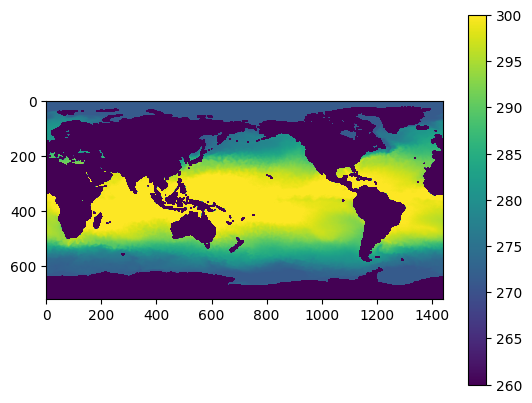

In [17]:

img = plt.imshow(fields[0,ich,:720, :])
cbar = plt.colorbar(img)
img.set_clim(260,300)

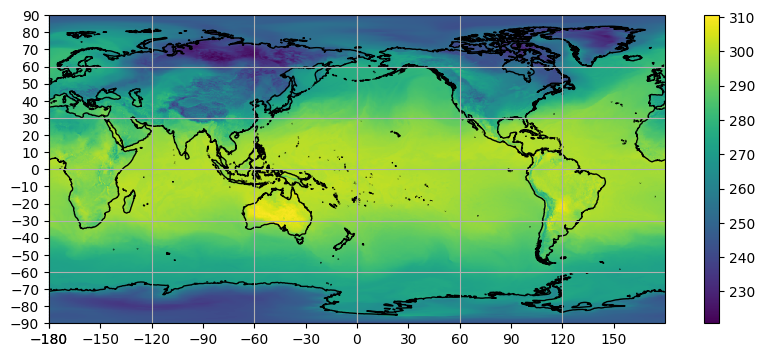

In [6]:
fig = plt.figure(figsize=(10, 4))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.coastlines(resolution="50m")
ax.set_xticks(range(0, 361, 30), crs=ccrs.PlateCarree())
ax.set_yticks(range(-90, 91, 10), crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=False)

# wind
lat = np.linspace(90, -90, fields.shape[2])
lon = np.linspace(0, 360, fields.shape[3])

#wave
# lat = np.arange(90, -90, -0.5)
# lon = np.arange(0, 360, 0.5)

lon, lat = np.meshgrid(lon, lat)

fig = ax.pcolormesh(lon, lat, fields[0,2,:720, :], transform=ccrs.PlateCarree(), cmap='viridis')
plt.colorbar(fig, ax=ax)